In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.metrics import mean_squared_error, r2_score
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import random
import warnings
np.random.seed(34)
warnings.filterwarnings('ignore')


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22720\1923021796.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
data=pd.read_csv('D:/bachelor semester/datasets/nasabattery.csv')

In [3]:
data.head()

,Unnamed: 0,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,0,4.246711,0.000252,6.212696,0.0002,0.000,0.000
1,1,4.246764,-0.001411,6.234019,0.0002,4.262,9.360
2,2,4.039277,-0.995093,6.250255,1.0000,3.465,23.281
3,3,4.019506,-0.996731,6.302176,1.0000,3.451,36.406
4,4,4.004763,-0.992845,6.361645,1.0000,3.438,49.625


<Axes: >

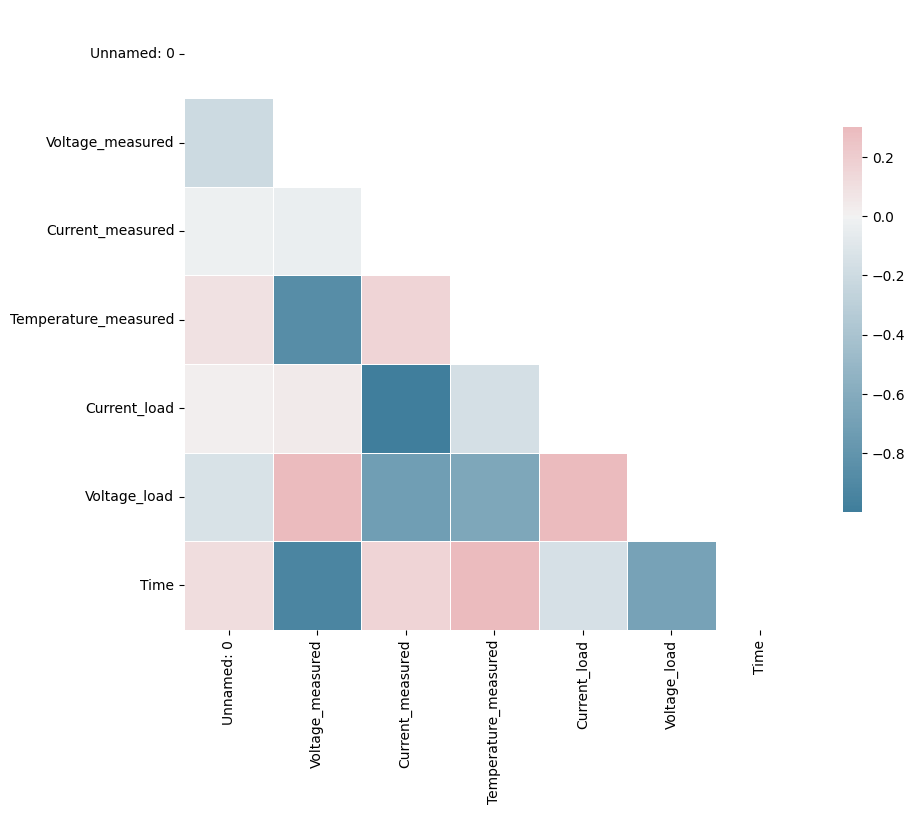

In [4]:
corr = data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(10, 10))
cmap = sns.diverging_palette(230, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,square=True, linewidths=.5, cbar_kws={"shrink": .5})

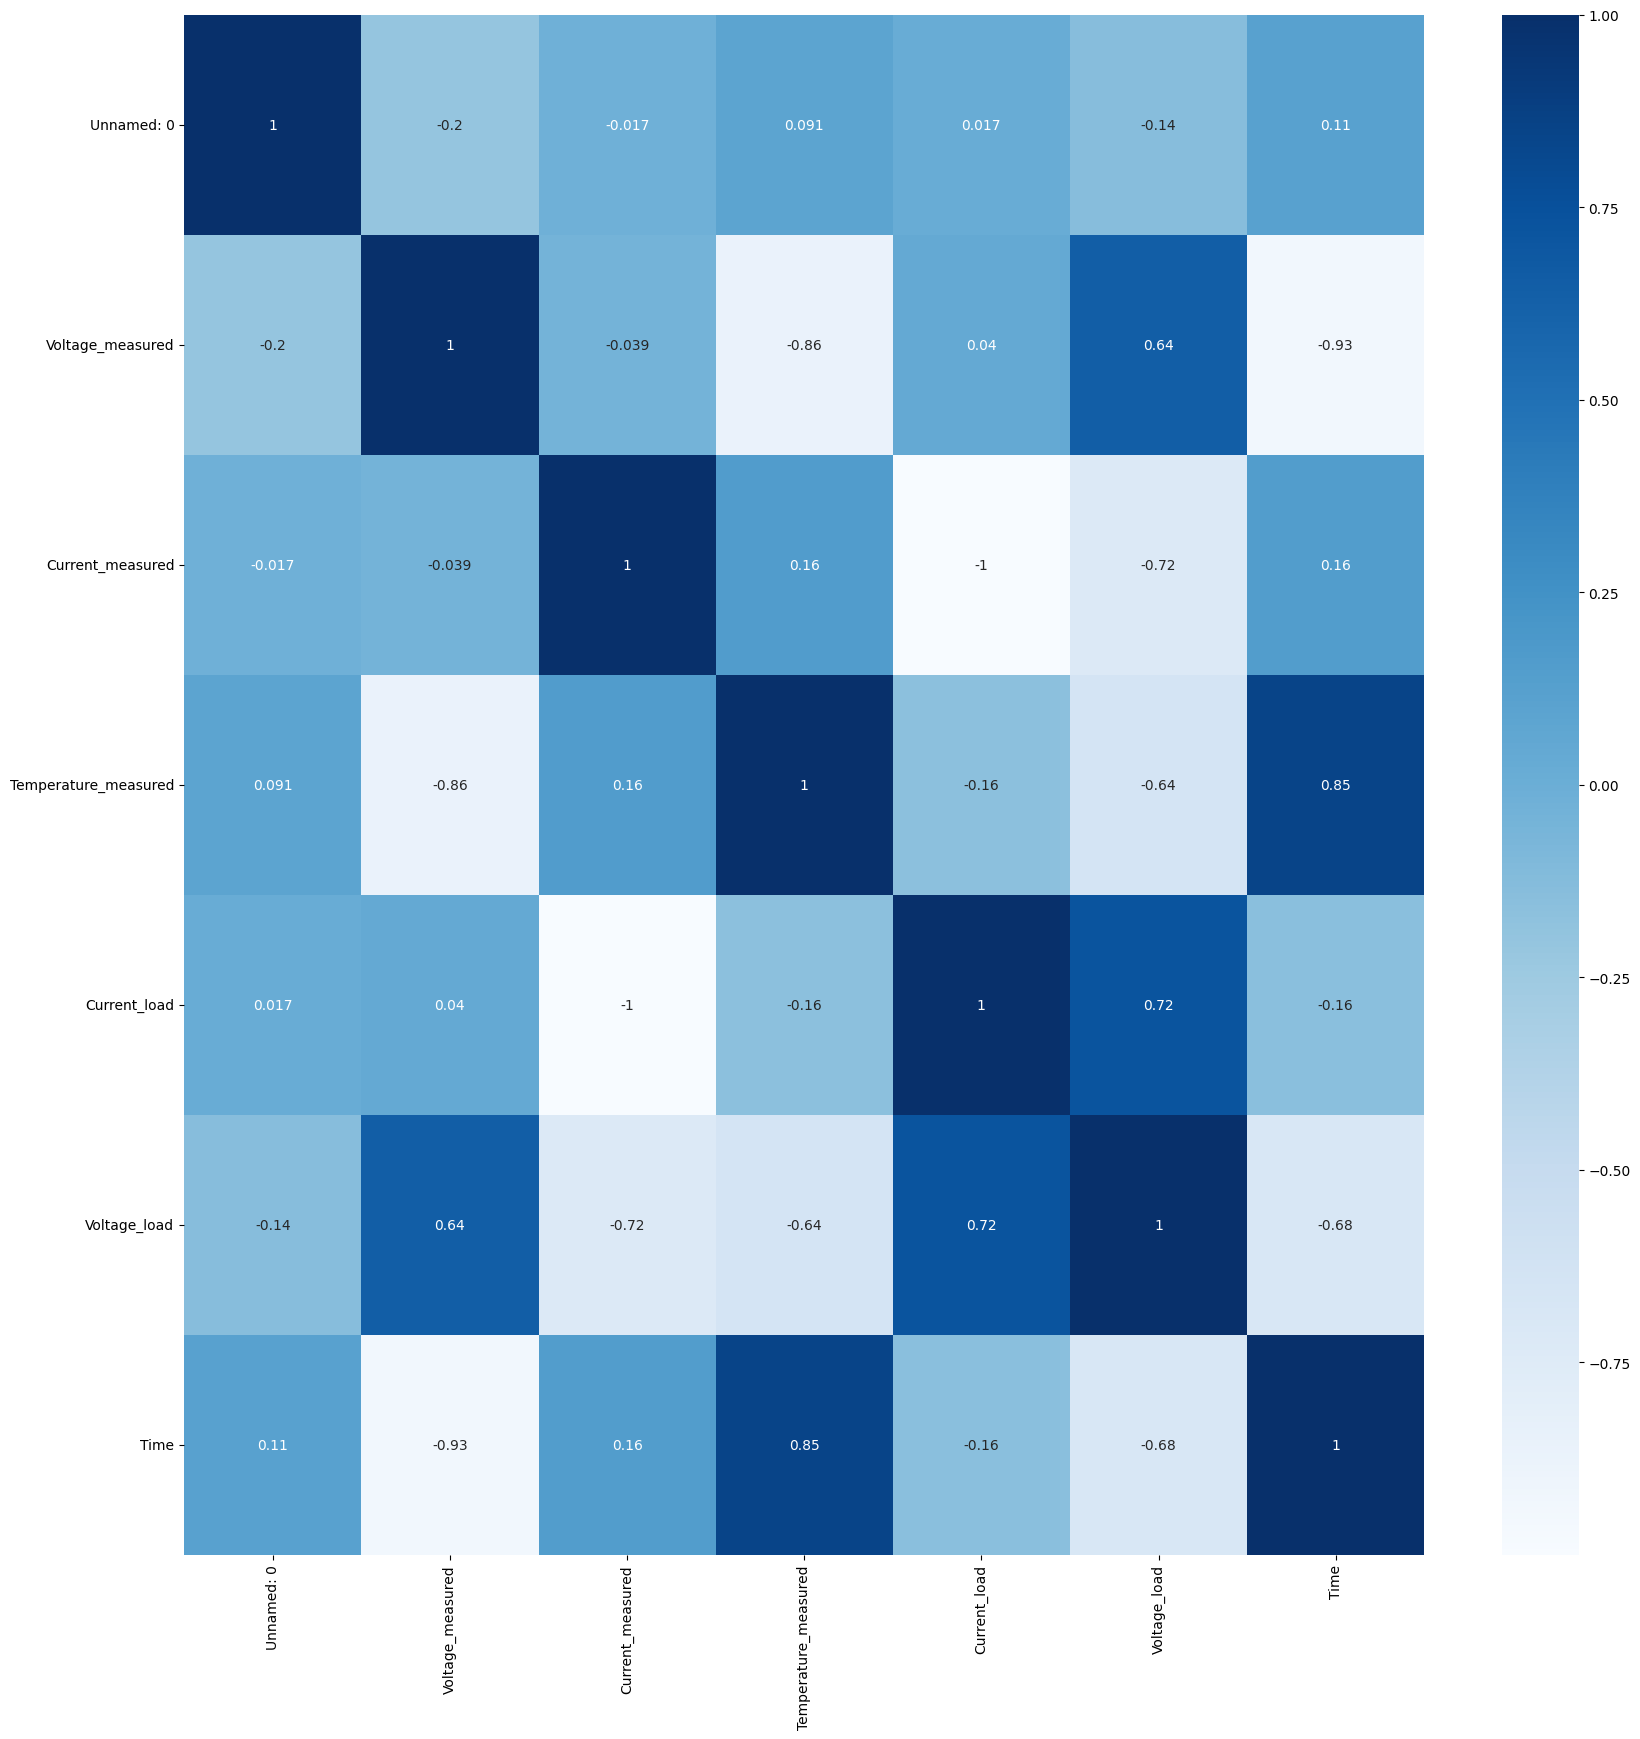

In [7]:
sns.heatmap(data.corr(),annot=True,cmap='Blues')
fig=plt.gcf()
fig.set_size_inches(20,20)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(data, test_size=0.2, random_state=42)

drop_cols = ['Current_load','Time']

train_y = train['Time']
train_X = train.drop(drop_cols, axis=1)

test_y = test['Time']
test_X = test.drop(drop_cols, axis=1)


from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
#Scaling X_train and X_test
x_train_scale=scaler.fit_transform(train_X)
x_test_scale=scaler.fit_transform(test_X)


In [9]:
#linear regression
from sklearn.linear_model import LinearRegression
modellr=LinearRegression()

#svr
from sklearn.svm import SVR
regressor = SVR(kernel='rbf')

#random_forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(max_features="sqrt", random_state=42)

In [10]:
#evaluating functions
#R2 score & RMSE & MAER
def evaluate(y_true, y_hat, label='test'):
    mse = mean_squared_error(y_true, y_hat)
    rmse = np.sqrt(mse)
    variance = r2_score(y_true, y_hat)
    print('{} set RMSE:{}, R2:{}'.format(label, rmse, variance))


#plot real data and the predicted one to make some comparison
def plot_predActual(y_test, y_test_hat):
  
    indices = np.arange(len(y_test_hat))
    wth= 0.6
    plt.figure(figsize=(70,30))
    true_values = [int(x) for x in y_test.values]
    predicted_values = list(y_test_hat)

    plt.bar(indices, true_values, width=wth,color='b', label='True RUL')
    plt.bar([i for i in indices], predicted_values, width=0.5*wth, color='r', alpha=0.7, label='Predicted RUL')

    plt.legend(prop={'size': 40})
    plt.tick_params(labelsize=40)

    plt.show()

test set RMSE:182.31880608478582, R2:0.9884999972258177
train set RMSE:9.772435406898905, R2:0.9999659570848681


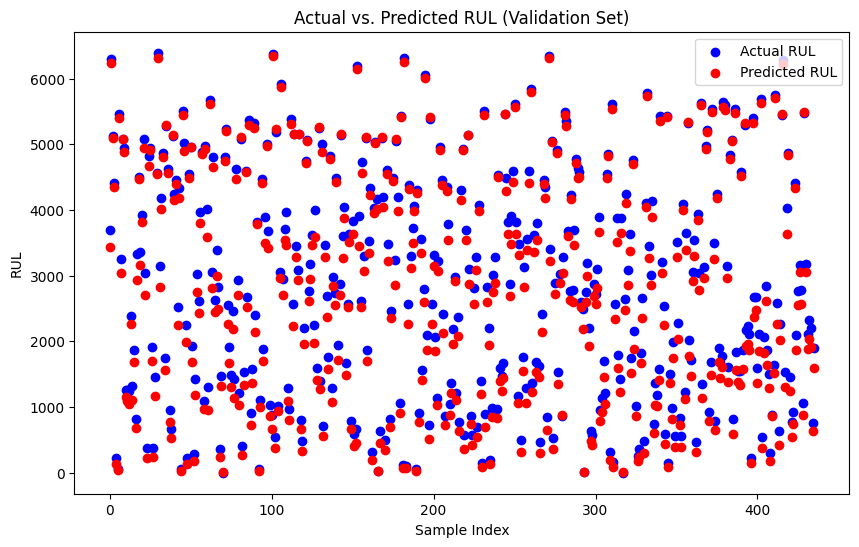

In [17]:
####bestmodel
modelr=RandomForestRegressor(n_estimators=100)

#training the model
modelr.fit(x_train_scale,train_y)


#model evaluate
test_data_prediction = modelr.predict(x_test_scale)
evaluate(test_y,test_data_prediction, label='test')


train_data_prediction = modelr.predict(x_train_scale)
evaluate(train_y,train_data_prediction, label='train')


y_pred = modelr.predict(x_test_scale)
plt.figure(figsize=(10, 6))
plt.scatter(range(len(test_y)), test_y, color='b', label='Actual RUL')
plt.scatter(range(len(y_pred)), y_pred, color='r', label='Predicted RUL')
plt.xlabel('Sample Index')
plt.ylabel('RUL')
plt.title('Actual vs. Predicted RUL (Validation Set)')
plt.legend()
plt.show()

test set RMSE:190.7312458963987, R2:0.9874142616121011
train set RMSE:5.600137735657302, R2:0.9999888205987965


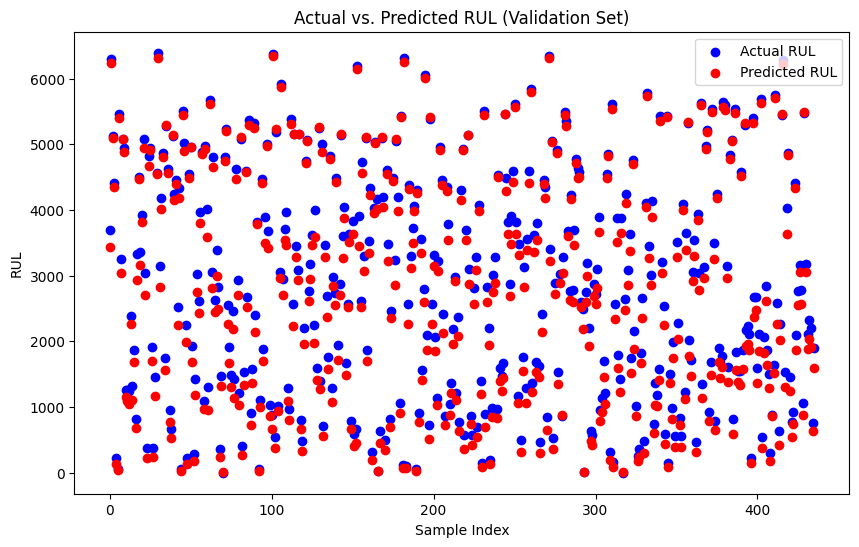

In [18]:
import xgboost as xgb

modelxgb = xgb.XGBRegressor(random_state=0)
modelxgb.fit(x_train_scale, train_y)

#model evaluate
test_data_prediction = modelxgb.predict(x_test_scale)
evaluate(test_y,test_data_prediction, label='test')


train_data_prediction = modelxgb.predict(x_train_scale)
evaluate(train_y,train_data_prediction, label='train')


y_pred = modelr.predict(x_test_scale)
plt.figure(figsize=(10, 6))
plt.scatter(range(len(test_y)), test_y, color='b', label='Actual RUL')
plt.scatter(range(len(y_pred)), y_pred, color='r', label='Predicted RUL')
plt.xlabel('Sample Index')
plt.ylabel('RUL')
plt.title('Actual vs. Predicted RUL (Validation Set)')
plt.legend()
plt.show()

test set RMSE:558.0363649475719, R2:0.8922642074592487
train set RMSE:566.7552557426596, R2:0.8854982201800472


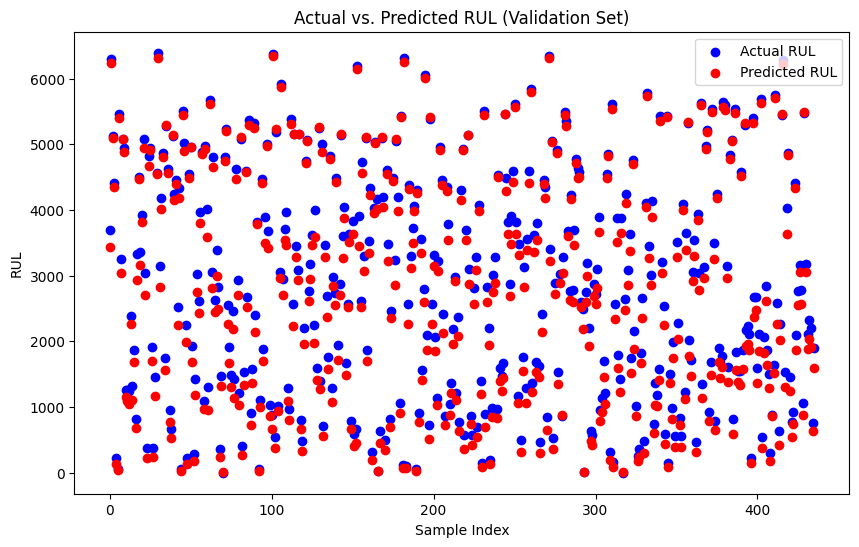

In [19]:
#randomtreeregression
modellr.fit(x_train_scale,train_y) 

#model evaluate
test_data_prediction = modellr.predict(x_test_scale)
evaluate(test_y,test_data_prediction, label='test')


train_data_prediction = modellr.predict(x_train_scale)
evaluate(train_y,train_data_prediction, label='train')

y_pred = modelr.predict(x_test_scale)
plt.figure(figsize=(10, 6))
plt.scatter(range(len(test_y)), test_y, color='b', label='Actual RUL')
plt.scatter(range(len(y_pred)), y_pred, color='r', label='Predicted RUL')
plt.xlabel('Sample Index')
plt.ylabel('RUL')
plt.title('Actual vs. Predicted RUL (Validation Set)')
plt.legend()
plt.show()

train set RMSE:1554.3705253677642, R2:0.13874802702740274
test set RMSE:1582.0146864176293, R2:0.13412334547044058


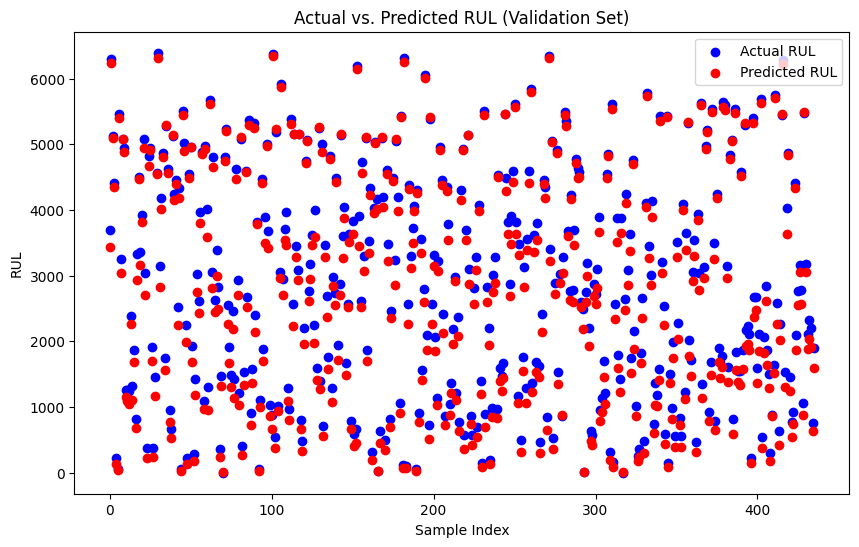

In [20]:
#SVR
regressor.fit(x_train_scale, train_y) # fitting

y_svr_train = regressor.predict(x_train_scale) #Prediction on train data
evaluate(train_y,y_svr_train, label='train')

y_svr_test = regressor.predict(x_test_scale) #Prediction on test data
evaluate(test_y, y_svr_test, label='test')

y_pred = modelr.predict(x_test_scale)
plt.figure(figsize=(10, 6))
plt.scatter(range(len(test_y)), test_y, color='b', label='Actual RUL')
plt.scatter(range(len(y_pred)), y_pred, color='r', label='Predicted RUL')
plt.xlabel('Sample Index')
plt.ylabel('RUL')
plt.title('Actual vs. Predicted RUL (Validation Set)')
plt.legend()
plt.show()